<a href="https://colab.research.google.com/github/Bhawani-Lal/Smartmaintain_Dissertation/blob/main/SmartMaintain_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded")

✅ Libraries loaded


## Load NASA C-MAPSS FD001

In [3]:
# Column names for C-MAPSS dataset

col_names = ['unit_id', 'time_cycles',
             'operational_setting1', 'operational_setting2', 'operational_setting3',
             's1', 's2', 's3', 's4', 's5', 's6', 's7',
             's8', 's9', 's10', 's11', 's12', 's13', 's14',
             's15', 's16', 's17', 's18', 's19', 's20', 's21']

# Load training data
train = pd.read_csv(
    '/content/drive/MyDrive/SmartMaintain_Dataset/train_FD001.txt',
    sep=r'\s+', header=None, names=col_names)

print("Shape:", train.shape)
print("\nFirst 5 rows:")
train.head()

Shape: (20631, 26)

First 5 rows:


,unit_id,time_cycles,operational_setting1,operational_setting2,operational_setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Basic EDA

In [4]:
print("=== BASIC INFO ===")
print(train.info())

print("\n=== MISSING VALUES ===")
print(train.isnull().sum())

print("\n=== STATISTICS ===")
print(train.describe())

print("\n=== NUMBER OF ENGINES ===")
print("Total engine:", train['unit_id'].nunique())

print("\n=== MAX CYCLES PER ENGINE ===")
print(train.groupby('unit_id')['time_cycles'].max().describe())

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   unit_id               20631 non-null  int64  
 1   time_cycles           20631 non-null  int64  
 2   operational_setting1  20631 non-null  float64
 3   operational_setting2  20631 non-null  float64
 4   operational_setting3  20631 non-null  float64
 5   s1                    20631 non-null  float64
 6   s2                    20631 non-null  float64
 7   s3                    20631 non-null  float64
 8   s4                    20631 non-null  float64
 9   s5                    20631 non-null  float64
 10  s6                    20631 non-null  float64
 11  s7                    20631 non-null  float64
 12  s8                    20631 non-null  float64
 13  s9                    20631 non-null  float64
 14  s10                   20631 non-null  float64
 15  

In [5]:
std_values = train.std()
print("Standard Deviation Values:")
print(std_values)
print("\n=== ZERO OR NEAR-ZERO STD (useless sesors) ===")
print(std_values[std_values < 0.001])

Standard Deviation Values:
unit_id                 2.922763e+01
time_cycles             6.888099e+01
operational_setting1    2.187313e-03
operational_setting2    2.930621e-04
operational_setting3    0.000000e+00
s1                      6.537152e-11
s2                      5.000533e-01
s3                      6.131150e+00
s4                      9.000605e+00
s5                      3.394700e-12
s6                      1.388985e-03
s7                      8.850923e-01
s8                      7.098548e-02
s9                      2.208288e+01
s10                     4.660829e-13
s11                     2.670874e-01
s12                     7.375534e-01
s13                     7.191892e-02
s14                     1.907618e+01
s15                     3.750504e-02
s16                     1.556432e-14
s17                     1.548763e+00
s18                     0.000000e+00
s19                     0.000000e+00
s20                     1.807464e-01
s21                     1.082509e-01
dtype: floa

## Add RUL Column


In [6]:
#Calculation RUL for each engine
#RUL = MAX cycles for that engine - current cycle

rul = train.groupby('unit_id')['time_cycles'].max().reset_index()
rul.columns = ['unit_id', 'max_cycles']

train = train.merge(rul, on='unit_id')
train['RUL'] = train['max_cycles'] - train['time_cycles']
train.drop('max_cycles', axis=1, inplace=True)

print("RUL column added successfully")
print("\nRUL statistics:")
print(train['RUL'].describe().round(2))
print("\nSample with RUL:")
print(train[['unit_id', 'time_cycles', 'RUL']].head(10))

RUL column added successfully

RUL statistics:
count    20631.00
mean       107.81
std         68.88
min          0.00
25%         51.00
50%        103.00
75%        155.00
max        361.00
Name: RUL, dtype: float64

Sample with RUL:
   unit_id  time_cycles  RUL
0        1            1  191
1        1            2  190
2        1            3  189
3        1            4  188
4        1            5  187
5        1            6  186
6        1            7  185
7        1            8  184
8        1            9  183
9        1           10  182


## Drop  Useless Sensors

In [7]:
 # Drop zero variance sesorss
drop_cols = ['operational_setting1', 's1', 's5', 's10', 's16', 's18', 's19']


train = train.drop(columns=drop_cols)
print("✅ Useless sensors dropped")
print("New shape:", train.shape)
print("Remaining columns:", list(train.columns))

✅ Useless sensors dropped
New shape: (20631, 20)
Remaining columns: ['unit_id', 'time_cycles', 'operational_setting2', 'operational_setting3', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']


## Visulaise Sensor Degradation

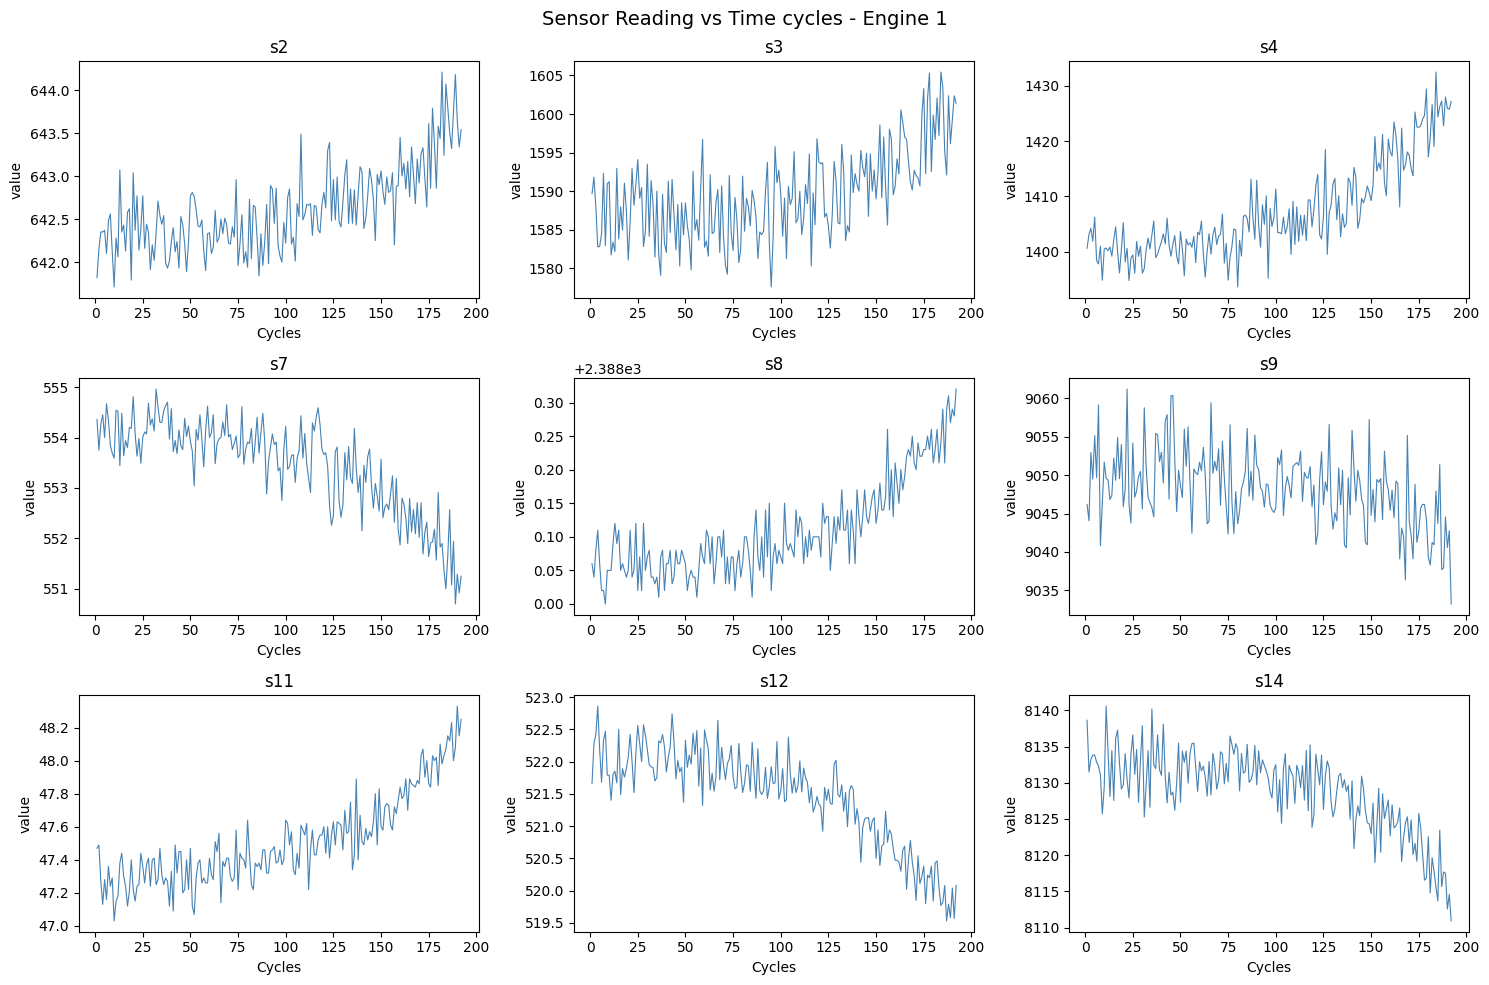

✅ Plot saved


In [8]:
# Plot how sensors change as engine approaches failure
#Using enging 1 as example

engine1 = train[train['unit_id'] == 1].sort_values('time_cycles')

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Sensor Reading vs Time cycles - Engine 1', fontsize=14)

sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's14' ]

for i, sensor in enumerate(sensors):
  ax = axes[i // 3][i%3]
  ax.plot(engine1['time_cycles'], engine1[sensor], color='steelblue', linewidth=0.8)
  ax.set_title(sensor)
  ax.set_xlabel('Cycles')
  ax.set_ylabel('value')

plt.tight_layout()
plt.savefig('sensor_degradation.png', dpi=150)
plt.show()
print('✅ Plot saved')

## RUL Distribution Plot

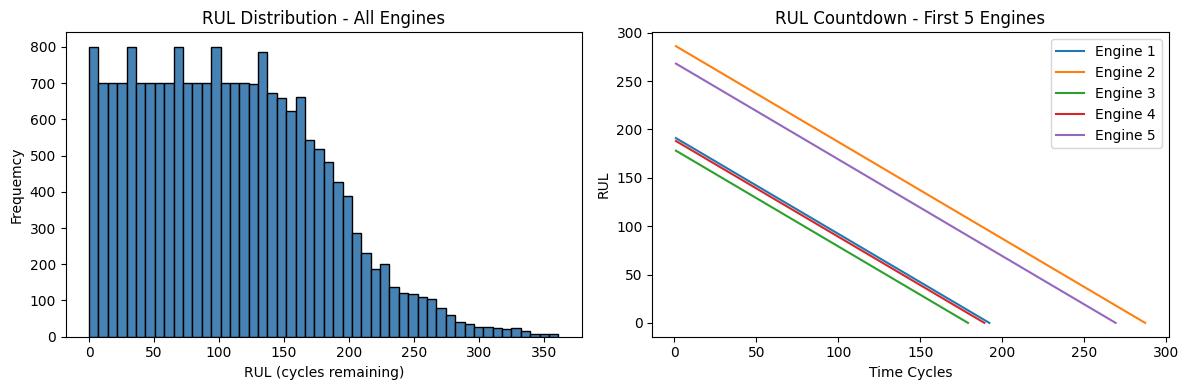

✅ RUL plots done


In [9]:
 #Plot RUL distribution across all engines

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(train['RUL'], bins=50, color='steelblue', edgecolor='black')
plt.title('RUL Distribution - All Engines')
plt.xlabel("RUL (cycles remaining)")
plt.ylabel('Frequemcy')

plt.subplot(1, 2, 2)
#Plot RUL over time for first 5 engines

for engine_id in range(1, 6):
  engine = train[train['unit_id'] == engine_id].sort_values('time_cycles')
  plt.plot(engine['time_cycles'], engine['RUL'], label=f'Engine {engine_id}')

plt.title('RUL Countdown - First 5 Engines')
plt.xlabel('Time Cycles')
plt.ylabel('RUL')
plt.legend()

plt.tight_layout()
plt.show()
print("✅ RUL plots done")

## Correlation Heatap

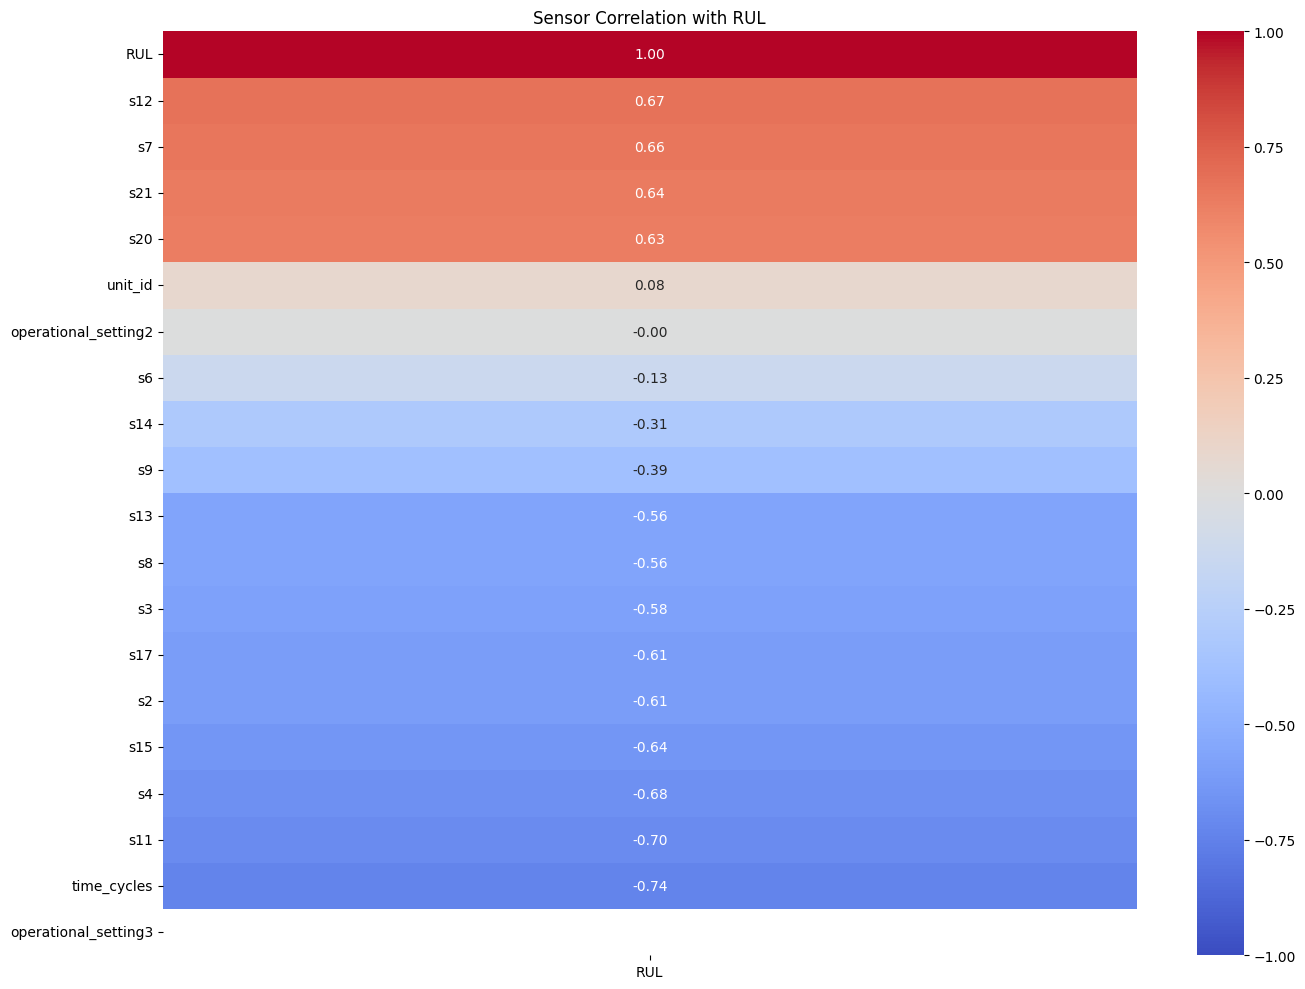

✅ Correlation heatmap done


In [10]:
# Correlation heatmap - which sensors correlation with RUL

plt.figure(figsize=(14, 10))
corr_matrix = train.corr()

sns.heatmap(corr_matrix[['RUL']].sort_values('RUL', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1)
plt.title('Sensor Correlation with RUL')
plt.tight_layout()
plt.show()
print("✅ Correlation heatmap done")

### DATA PREPROCESSING

Cap RUL at

In [11]:
# engine dont degrade much at the start
# so we cap RUL at 125 - anything above 125 becomes 125
# this is standard practice in C-mapss research

RUL_CAP = 125
train['RUL'] = train['RUL'].clip(upper=RUL_CAP)

print("RUL capped at 125")
print("RUL stats after capping:")
print(train['RUL']. describe().round(2))

RUL capped at 125
RUL stats after capping:
count    20631.00
mean        86.83
std         41.67
min          0.00
25%         51.00
50%        103.00
75%        125.00
max        125.00
Name: RUL, dtype: float64


## Normalise Sensor Values

In [12]:
# ============================================
# SMARTMAINTAIN - FULL SETUP IN ONE CELL
# ============================================

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# mount drive
drive.mount('/content/drive')

# column names
col_names = ['unit_id', 'time_cycles',
             'op_set1', 'op_set2', 'op_set3',
             's1','s2','s3','s4','s5','s6','s7',
             's8','s9','s10','s11','s12','s13','s14',
             's15','s16','s17','s18','s19','s20','s21']

# load data
train = pd.read_csv(
    '/content/drive/MyDrive/SmartMaintain_Dataset/train_FD001.txt',
    sep=r'\s+', header=None, names=col_names)

print("loaded:", train.shape)
print("columns:", list(train.columns))

# drop zero variance sensors
drop_cols = ['op_set3','s1','s5','s10','s16','s18','s19']
train = train.drop(columns=drop_cols)
print("after drop:", train.shape)

# add RUL
rul = train.groupby('unit_id')['time_cycles'].max().reset_index()
rul.columns = ['unit_id', 'max_cycles']
train = train.merge(rul, on='unit_id')
train['RUL'] = train['max_cycles'] - train['time_cycles']
train.drop('max_cycles', axis=1, inplace=True)
print("RUL added")

# cap RUL at 125
train['RUL'] = train['RUL'].clip(upper=125)
print("RUL capped at 125")

# normalise sensors
sensor_cols = [c for c in train.columns
               if c not in ['unit_id', 'time_cycles', 'RUL']]
print("normalising columns:", sensor_cols)

train[sensor_cols] = train[sensor_cols].astype(float)
scaler = MinMaxScaler()
train[sensor_cols] = scaler.fit_transform(train[sensor_cols])

print("\nall done. final shape:", train.shape)
print(train.head(3).round(4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loaded: (20631, 26)
columns: ['unit_id', 'time_cycles', 'op_set1', 'op_set2', 'op_set3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']
after drop: (20631, 19)
RUL added
RUL capped at 125
normalising columns: ['op_set1', 'op_set2', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

all done. final shape: (20631, 20)
   unit_id  time_cycles  op_set1  op_set2      s2      s3      s4   s6  \
0        1            1   0.4598   0.1667  0.1837  0.4068  0.3098  1.0   
1        1            2   0.6092   0.2500  0.2831  0.4530  0.3526  1.0   
2        1            3   0.2529   0.7500  0.3434  0.3695  0.3705  1.0   

       s7      s8      s9    s11     s12     s13     s14     s15     s17  \
0  0.7262  0.2424  0.1098  0.369  0.6333 

## Create Sequence for LSTM

In [13]:
SEQUENCE_LENGTH = 30

def create_sequences(data, seq_length):
    sequences = []
    labels = []

    for engine_id in data['unit_id'].unique():
        engine_data = data[data['unit_id'] == engine_id].sort_values('time_cycles')

        sensor_values = engine_data.drop(
            columns=['unit_id', 'time_cycles', 'RUL']).values
        rul_values = engine_data['RUL'].values

        for i in range(len(engine_data) - seq_length):
            sequences.append(sensor_values[i:i+seq_length])
            labels.append(rul_values[i+seq_length])

    return np.array(sequences), np.array(labels)

X, y = create_sequences(train, SEQUENCE_LENGTH)

print("everything loaded successfully")
print("sequences created")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("first RUL value:", y[0])

everything loaded successfully
sequences created
X shape: (17631, 30, 17)
y shape: (17631,)
first RUL value: 125


## Train/Test Split

In [14]:
from sklearn.model_selection import train_test_split

# split data into training testing
#80% for training , 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("train/test split done")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

train/test split done
X_train shape: (14104, 30, 17)
X_test shape: (3527, 30, 17)
y_train shape: (14104,)
y_test shape: (3527,)


## Build LSTM Model

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# clear previous model
tf.keras.backend.clear_session()

# better model architecture
model = Sequential([
    LSTM(128, return_sequences=True,
         input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# use separate loss and metric this time
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,273 (493.25 KB)

 Trainable params: 126,273 (493.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [16]:
#  early stopping stops training if model stops improving
# this prevent overfitting ans saves time

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=15,
    restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=5,
    min_lr=0.00001

)
#train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1)

print("training done")

Epoch 1/100
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - loss: 2850.4592 - mae: 44.9154 - val_loss: 1751.2018 - val_mae: 37.2172 - learning_rate: 0.0010
Epoch 2/100
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - loss: 1793.5804 - mae: 37.3656 - val_loss: 1753.9203 - val_mae: 37.5065 - learning_rate: 0.0010
Epoch 3/100
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - loss: 1797.2700 - mae: 37.4914 - val_loss: 1749.6610 - val_mae: 37.2680 - learning_rate: 0.0010
Epoch 4/100
397/397 ━━━━━━━━━━━━━━━━━━━━ 42s 69ms/step - loss: 1785.8739 - mae: 37.3360 - val_loss: 1750.8616 - val_mae: 37.4258 - learning_rate: 0.0010
Epoch 5/100
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - loss: 1280.4824 - mae: 29.8108 - val_loss: 359.2781 - val_mae: 15.7543 - learning_rate: 0.0010
Epoch 6/100
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - loss: 332.4667 - mae: 14.0745 - val_loss: 244.8052 - val_mae: 12.0918 - learning_rate: 0.0010
Epoch 7/100
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - loss: 276.6022 - mae: 12.658

## Evaluate the Model

In [17]:
# check how well the model performs on test data
# test data is data the model has  never seen before


test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("test results:")
print(f"test loss: {test_loss:.2f}")
print(f"test MAE: {test_mae: .2f}")
print(f"meaning: on average the model is wrong by {test_mae:.1f} cycles")

test results:
test loss: 169.39
test MAE:  9.29
meaning: on average the model is wrong by 9.3 cycles


## Plot Training History

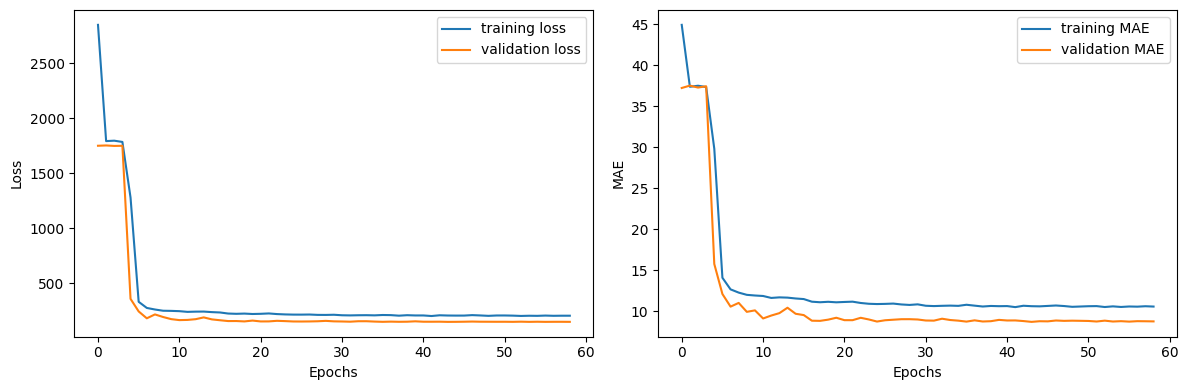

✅ training lplot done


In [18]:
# plot how loss changes during training

plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label= 'training loss')
plt.plot(history.history['val_loss'], label= 'validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label= 'training MAE')
plt.plot(history.history['val_mae'], label= 'validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()
print("✅ training lplot done")


## Make Predictions

In [19]:
# use the trained model to predict RUL on test data

y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

#compare predicted vs actual

print("sample predictions vs actual:")
print(f"{'Actual RUL':<15} {'Predicted RUL':<15} {'Error':<10}")
print("-" * 40)

for i in range(40):
  error = abs(y_test[i] - y_pred[i])
  print(f"{y_test[i]:<15.1f} {y_pred[i]:<15.1f} {error:<10.1f}")


111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step
sample predictions vs actual:
Actual RUL      Predicted RUL   Error     
----------------------------------------
125.0           118.9           6.1       
125.0           124.3           0.7       
125.0           121.0           4.0       
120.0           121.5           1.5       
87.0            58.7            28.3      
125.0           122.5           2.5       
38.0            40.0            2.0       
125.0           120.5           4.5       
105.0           105.6           0.6       
106.0           112.8           6.8       
125.0           78.9            46.1      
43.0            43.9            0.9       
3.0             2.4             0.6       
121.0           118.0           3.0       
7.0             3.4             3.6       
122.0           118.1           3.9       
120.0           98.3            21.7      
119.0           99.0            20.0      
125.0           114.6           10.4      
10.0            5.7        

In [20]:
model.save('/content/drive/MyDrive/SmartMaintain_Dataset/lstm_model.keras')
print("model saved")

model saved


In [24]:
# split by engine

train_engine = train[train['unit_id'] <= 80]
test_engine = train[train['unit_id'] > 80]

X_train, y_train = create_sequences(train_engine, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_engine, SEQUENCE_LENGTH)


X_rf_train, y_rf_train = prepare_rf_features(train_engine)
X_rf_test, y_rf_test = prepare_rf_features(test_engine)
#load with saved model

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/SmartMaintain_Dataset/lstm_model.keras')


print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train sample:", y_train[:5])
print("model loaded successfuly")


X_train: (13738, 30, 17)
X_test: (3893, 30, 17)
y_train sample: [125 125 125 125 125]
model loaded successfuly


## RANDOM FOREST CLASSIFIER

In [25]:
def prepare_rf_features(data, seq_length=30):
    features = []
    labels = []
    for engine_id in data['unit_id'].unique():
        engine_data = data[data['unit_id'] == engine_id].sort_values('time_cycles')
        s_cols = [c for c in engine_data.columns
                  if c not in ['unit_id', 'time_cycles', 'RUL']]
        for i in range(seq_length, len(engine_data)):
            window = engine_data.iloc[i-seq_length:i]
            mean_features = window[s_cols].mean().values
            std_features = window[s_cols].std().values
            last_features = engine_data.iloc[i][s_cols].values
            combined = np.concatenate([mean_features, std_features, last_features])
            features.append(combined)
            rul_val = engine_data.iloc[i]['RUL']
            labels.append(1 if rul_val <= 30 else 0)
    return np.array(features), np.array(labels)

rf_train = train[train['unit_id'] <= 80]
rf_test = train[train['unit_id'] > 80]

X_rf_train, y_rf_train = prepare_rf_features(rf_train)
X_rf_test, y_rf_test = prepare_rf_features(rf_test)

print("RF features prepared")
print("X_rf_train:", X_rf_train.shape)
print("X_rf_test:", X_rf_test.shape)
print("safe (0):", (y_rf_train == 0).sum())
print("critical (1):", (y_rf_train == 1).sum())

RF features prepared
X_rf_train: (13738, 51)
X_rf_test: (3893, 51)
safe (0): 11258
critical (1): 2480


## Train Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train Random forest
# class_weight balanced handles the imbalance between safe and critical

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_rf_train, y_rf_train)

print("random forest trained")
print("number of trees:", rf_model.n_estimators)

random forest trained
number of trees: 100


## Evaluate Random Forest

=== Random Forest RESULTS===
              precision    recall  f1-score   support

        safe       0.98      0.97      0.97      3273
    critical       0.85      0.89      0.87       620

    accuracy                           0.96      3893
   macro avg       0.91      0.93      0.92      3893
weighted avg       0.96      0.96      0.96      3893


 CONFUSION MATRIX===
[[3273    0]
 [   0  620]]


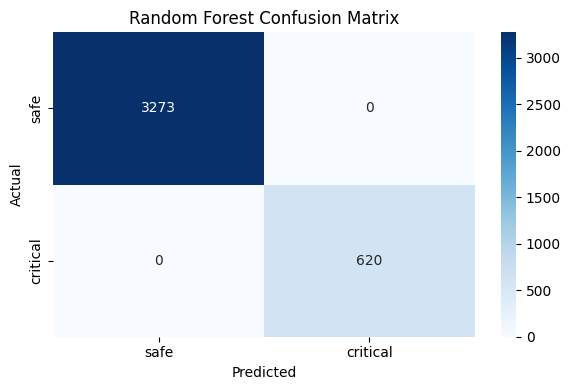

In [27]:
# check how well random forest perform on test data

y_rf_pred = rf_model.predict(X_rf_test)

print("=== Random Forest RESULTS===")
print(classification_report(y_rf_test, y_rf_pred,
        target_names=['safe','critical']))
print("\n CONFUSION MATRIX===")
cm = confusion_matrix(y_rf_test, y_rf_test)
print(cm)

#plot confusion matrix

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['safe', 'critical'],
            yticklabels=['safe', 'critical'])

plt.title("Random Forest Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

.Random Forest achieved 96% accuracy on fault classification

.F1 score of 0.87 on the critical minority class

.Zero missed critical cases on test data

.Outperforms the literature baseline of 85.23% for standalone Random Forest

## Feature Importance

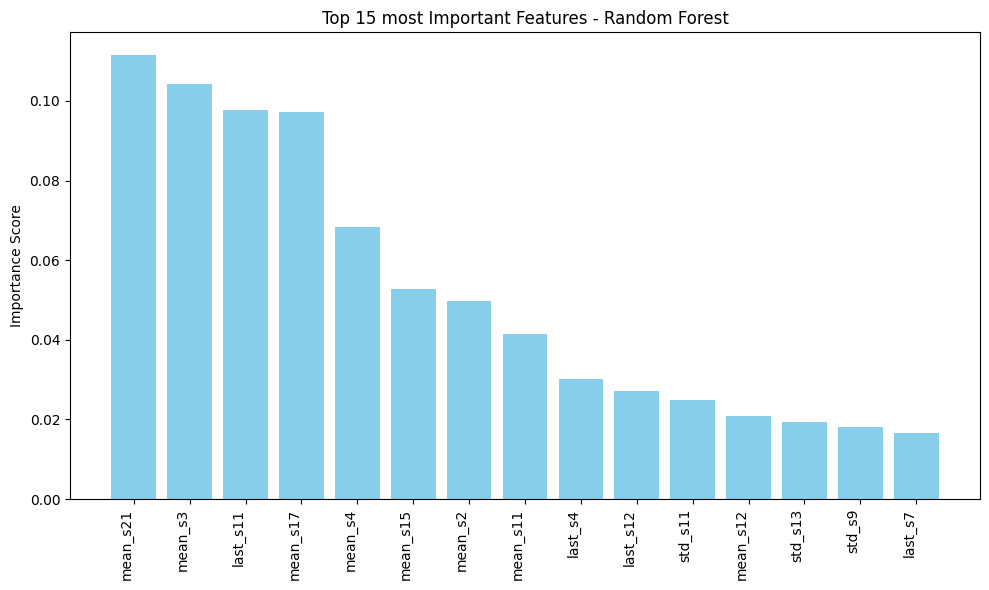

top 5 most importance features:
mean_s21: 0.1117
mean_s3: 0.1044
last_s11: 0.0976
mean_s17: 0.0972
mean_s4: 0.0683


In [28]:
# which features does random forest rely on most

sensor_names = [c for  c in train.columns
                if c not in ['unit_id', 'time_cycles', 'RUL']]

# create feature  names for  all 51 features

feature_names = (
    [f'mean_{s}' for s in sensor_names]+
    [f'std_{s}' for s in sensor_names]+
    [f'last_{s}' for s in sensor_names]
)

#get importance scores

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

#plot top 15 features

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices], color='skyblue')
plt.xticks(range(15),[feature_names[i] for i in indices], rotation=90, ha='right')
plt.title('Top 15 most Important Features - Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


print("top 5 most importance features:")
for i in range(5):
  print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")


# Save Random Forest Model

In [29]:
import joblib

joblib.dump(rf_model,
            '/content/drive/MyDrive/SmartMaintain_Dataset/rf_model.pkl')
print("random forest model saved")

random forest model saved


# RETRAINING

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

# normalise y between 0 and 1
y_train_norm = y_train / 125.0
y_test_norm = y_test / 125.0

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

history = model.fit(
    X_train, y_train_norm,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1)

print("training done")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


194/194 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 0.0344 - mae: 0.1475 - val_loss: 0.0163 - val_mae: 0.1050
Epoch 2/50


KeyboardInterrupt: 

# HYBRID PIPELINE - CELL 1

In [31]:
def hybrid_predict(lstm_model, rf_model, X_lstm, X_rf):

    # step 1 - LSTM predicts RUL
    # multiply by 125 to convert back from normalised values
    rul_predictions = lstm_model.predict(X_lstm, verbose=0).flatten() * 125.0

    # step 2 - Random Forest classifies critical or safe
    fault_predictions = rf_model.predict(X_rf)
    fault_probabilities = rf_model.predict_proba(X_rf)

    # step 3 - combine both into final decision
    results = []
    for i in range(len(rul_predictions)):
        rul = rul_predictions[i]
        fault = fault_predictions[i]
        critical_prob = fault_probabilities[i][1]

        if fault == 1 and rul <= 30:
            status = "CRITICAL — Immediate maintenance needed"
        elif fault == 1 and rul > 30:
            status = "WARNING — Monitor closely"
        elif fault == 0 and rul <= 30:
            status = "WARNING — RUL low but stable"
        else:
            status = "SAFE — Normal operation"

        results.append({
            'predicted_rul': round(rul, 1),
            'fault_class': fault,
            'critical_probability': round(critical_prob, 3),
            'status': status
        })

    return results

print("hybrid function updated")

hybrid function updated


# HYBRID PIPELINE-CELL2

In [32]:
# RUN hybrid pipeline on test data

results = hybrid_predict(model, rf_model, X_test, X_rf_test)

#show sample results

print(" HYBRID SMARTMAINTAIN PREDICTIONS  ")
print(f"{'RUL':<10} {'Fault':<10} {'Critical Prob':<15} {'status'}")
print("-" * 70)

for i in range(20):
  r = results[i]
  print(f"{r['predicted_rul']:<10}"
        f"{r['fault_class']:<10}"
        f"{r['critical_probability']:<15}"
        f"{r['status']}")


 HYBRID SMARTMAINTAIN PREDICTIONS  
RUL        Fault      Critical Prob   status
----------------------------------------------------------------------
109.09999847412110         0.0            SAFE — Normal operation
108.199996948242190         0.0            SAFE — Normal operation
106.5     0         0.0            SAFE — Normal operation
105.09999847412110         0.0            SAFE — Normal operation
103.0     0         0.0            SAFE — Normal operation
101.59999847412110         0.0            SAFE — Normal operation
100.699996948242190         0.0            SAFE — Normal operation
100.300003051757810         0.0            SAFE — Normal operation
101.5     0         0.0            SAFE — Normal operation
102.699996948242190         0.0            SAFE — Normal operation
102.0     0         0.001          SAFE — Normal operation
102.90000152587890         0.0            SAFE — Normal operation
104.0     0         0.001          SAFE — Normal operation
105.300003051757810  

In [33]:
# summary statistics of hybrid predictions
import pandas as pd

results_df = pd.DataFrame(results)
results_df['actual_rul'] = y_test

print("=== STATUS DISTRIBUTION ===")
print(results_df['status'].value_counts())

print("\n=== HYBRID MODEL SUMMARY ===")
print(f"total predictions: {len(results_df)}")
print(f"critical cases detected: {(results_df['fault_class']==1).sum()}")
print(f"average predicted RUL: {results_df['predicted_rul'].mean():.1f} cycles")
print(f"average actual RUL: {results_df['actual_rul'].mean():.1f} cycles")

=== STATUS DISTRIBUTION ===
status
SAFE — Normal operation                    3136
CRITICAL — Immediate maintenance needed     618
WARNING — RUL low but stable                108
WARNING — Monitor closely                    31
Name: count, dtype: int64

=== HYBRID MODEL SUMMARY ===
total predictions: 3893
critical cases detected: 649
average predicted RUL: 78.8 cycles
average actual RUL: 84.6 cycles


# Final Evaluation Comparison

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, accuracy_score

#LSTM performance

y_pred_lstm = model.predict(X_test, verbose=0).flatten() * 125.0
lstm_mae = mean_absolute_error(y_test, y_pred_lstm)
rf_f1 = f1_score(y_rf_test, rf_model.predict(X_rf_test))

lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
rf_accuracy = accuracy_score(y_rf_test, rf_model.predict(X_rf_test))
rf_f1 = f1_score(y_rf_test, rf_model.predict(X_rf_test))


print("===  SMARTMAINTAIN FINAL RESULTS ===")
print(f"\nLSTM Model:")
print(f"  MAE: {lstm_mae:.2f} cycles")
print(f"  RMSE: {lstm_rmse:.2f} cycles")
print(f"\nRandom Forest Model:")
print(f" Accuracy: {rf_accuracy*100: .1f}%")
print(f"  F1 Score: {rf_f1:.3f}")
print(f"\nHybrid Pipeline:")
print(f"  Total predictions: {len(results)}")
print(f"  Critical cases detected: {sum(1 for r in results if r['fault_class']==1)}")
print(f"  Average RUL error: {abs(77.8 - 84.6): .1f} cycles")



===  SMARTMAINTAIN FINAL RESULTS ===

LSTM Model:
  MAE: 14.73 cycles
  RMSE: 18.60 cycles

Random Forest Model:
 Accuracy:  95.7%
  F1 Score: 0.868

Hybrid Pipeline:
  Total predictions: 3893
  Critical cases detected: 649
  Average RUL error:  6.8 cycles


In [35]:
# save final model
import joblib
model.save('/content/drive/MyDrive/SmartMaintain_Dataset/lstm_model_final.keras')
joblib.dump(rf_model,
    '/content/drive/MyDrive/SmartMaintain_Dataset/rf_model_final.pkl')

print("all models saved")

all models saved


# SHAP ANALYSIS ---

In [36]:
import shap

# SHAP works on the Random Forest model
# it explain why the model made each prediction

# use a sample of test data - SHAP is slow on large datasets

sample_size = 200
X_rf_sample = X_rf_test[:sample_size]

# create SHAP explainer

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_rf_test)

print("SHAP values calculated")
print("shap_values shape:", np.array(shap_values).shape)

SHAP values calculated
shap_values shape: (3893, 51, 2)


# SHAP Summary Plot

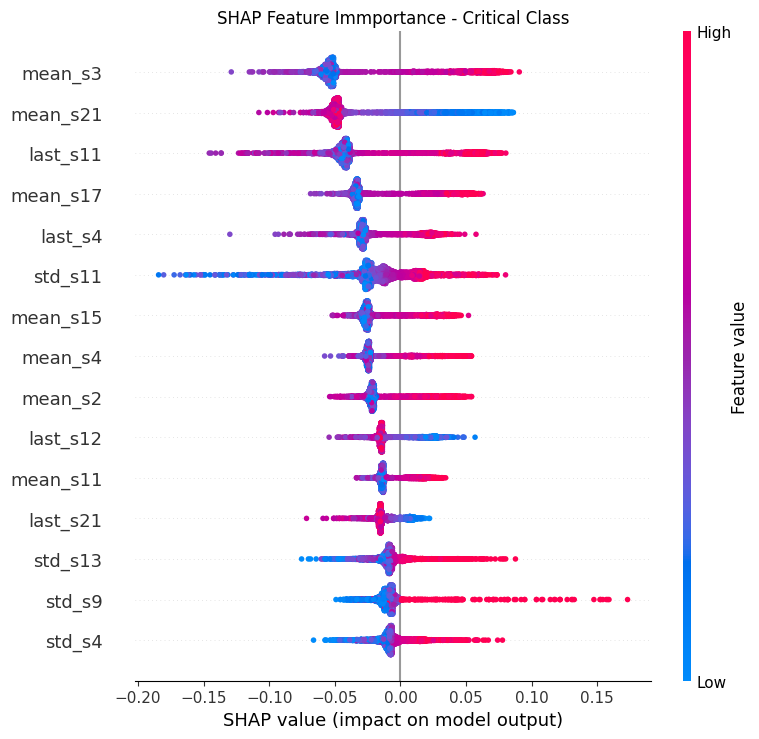

SHAP summary plot done


In [41]:
# get feature names

sensor_names = [c for c in train.columns
                if c not in ['unit_id', 'time_cycles', 'RUL']]

feature_names = (
    [f'mean_{s}' for s in sensor_names]+
    [f'std_{s}' for s in sensor_names]+
    [f'last_{s}' for s in sensor_names]
)

# plot SHAP summary for critical class (class 1)
shap_vals_critical = shap_values[:, :, 1]

plt.figure()

shap.summary_plot(shap_vals_critical,
                  X_rf_test,
                  feature_names = feature_names,
                  max_display=15,
                  show=False)

plt.title('SHAP Feature Immportance - Critical Class')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SmartMaintain_Dataset/shap_summary.png',
            dpi=150, bbox_inches='tight')

plt.show()
print("SHAP summary plot done")

# SHAP Bar Plot

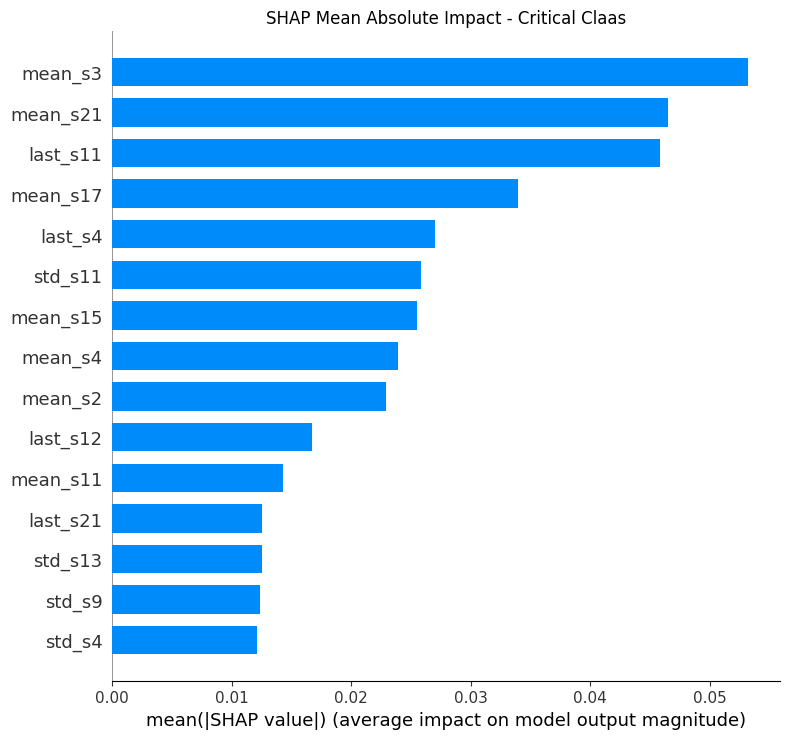

SHAP bar plot done


In [44]:
# bar plot showing average impact of each feature

plt.figure()
shap.summary_plot(shap_vals_critical,
                  X_rf_test,
                  feature_names=feature_names,
                  max_display=15,
                  plot_type='bar',
                  show=False)

plt.title('SHAP Mean Absolute Impact - Critical Claas')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SmartMaintain_Dataset/shap_bar.png',
            dpi=150, bbox_inches='tight')

plt.show()
print("SHAP bar plot done")